Import Library


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting tampilan
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

Load & Gabungkan Dataset

In [3]:
# Load semua file
orders   = pd.read_csv('../data/olist_orders_dataset.csv')
items    = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
transl   = pd.read_csv('../data/product_category_name_translation.csv')

# Gabungkan
df = items.merge(orders, on='order_id') \
          .merge(products, on='product_id') \
          .merge(transl, on='product_category_name', how='left')

print("Shape:", df.shape)
df.head()

Shape: (112650, 23)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


Cek Data Awal

In [4]:
print("=== INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== STATISTIK DESKRIPTIF ===")
df.describe()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   customer_id                    112650 non-null  object 
 8   order_status                   112650 non-null  object 
 9   order_purchase_timestamp       112650 non-null  object 
 10  order_approved_at              112635 non-null  object 
 11  order_delivered_carrier_date   111456 non-null  object 
 12  order_delivered_c

,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,112650.000000,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000
mean,1.197834,120.653739,19.990320,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546
std,0.705124,183.633928,15.806405,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268
min,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,1.000000,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,1.000000,134.900000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


Konversi Tanggal & Buat Fitur Waktu

In [5]:
# Konversi ke datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Ekstrak fitur waktu
df['tahun']  = df['order_purchase_timestamp'].dt.year
df['bulan']  = df['order_purchase_timestamp'].dt.month
df['minggu'] = df['order_purchase_timestamp'].dt.isocalendar().week.astype(int)
df['hari']   = df['order_purchase_timestamp'].dt.dayofweek  # 0=Senin

print("Rentang data:", df['order_purchase_timestamp'].min(), "→", df['order_purchase_timestamp'].max())

Rentang data: 2016-09-04 21:15:19 → 2018-09-03 09:06:57


Visualisasi Tren Penjualan per Bulan

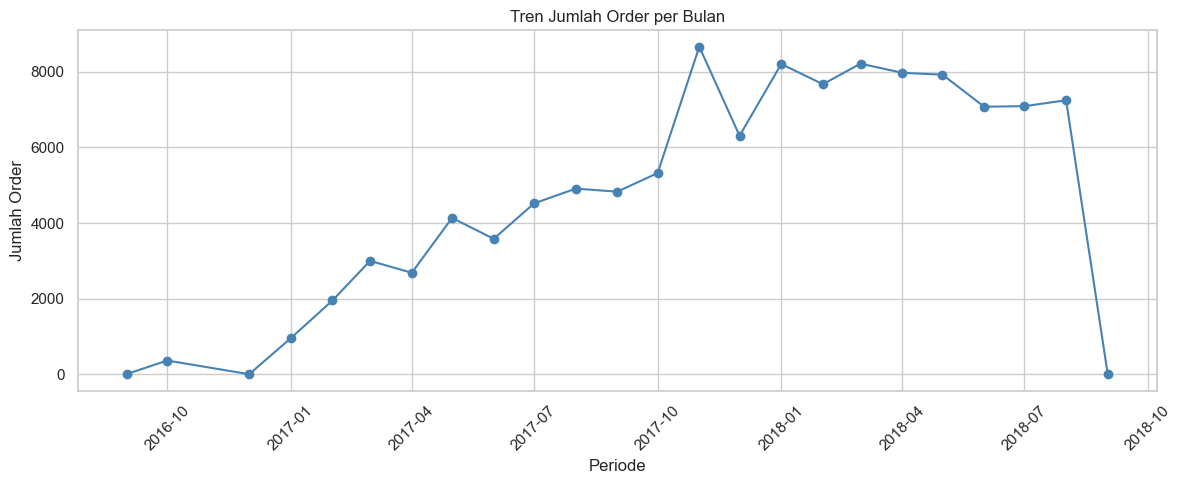

In [8]:
tren = df.groupby(['tahun', 'bulan'])['order_id'].count().reset_index()
tren['periode'] = pd.to_datetime({
    'year': tren['tahun'],
    'month': tren['bulan'],
    'day': 1
})
plt.figure()
plt.plot(tren['periode'], tren['order_id'], marker='o', color='steelblue')
plt.title('Tren Jumlah Order per Bulan')
plt.xlabel('Periode')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/tren_penjualan.png', dpi=150)
plt.show()

Top 10 Kategori Produk Terlaris

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12252\1430133787.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_kategori.values, y=top_kategori.index, palette='Blues_r')


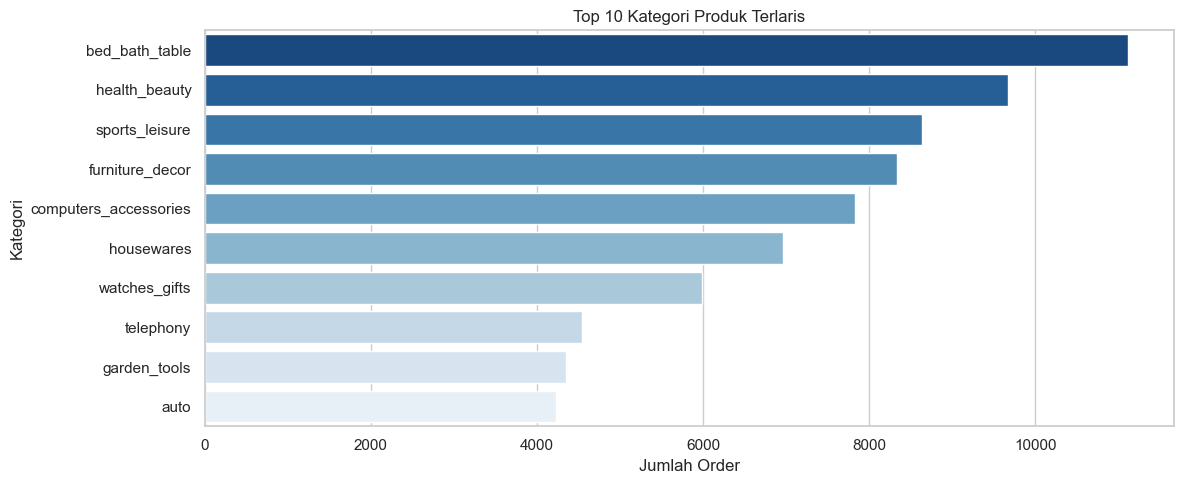

In [10]:
top_kategori = df.groupby('product_category_name_english')['order_id'] \
                 .count().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=top_kategori.values, y=top_kategori.index, palette='Blues_r')
plt.title('Top 10 Kategori Produk Terlaris')
plt.xlabel('Jumlah Order')
plt.ylabel('Kategori')
plt.tight_layout()
plt.savefig('../results/top_kategori.png', dpi=150)
plt.show()

Distribusi Harga Produk

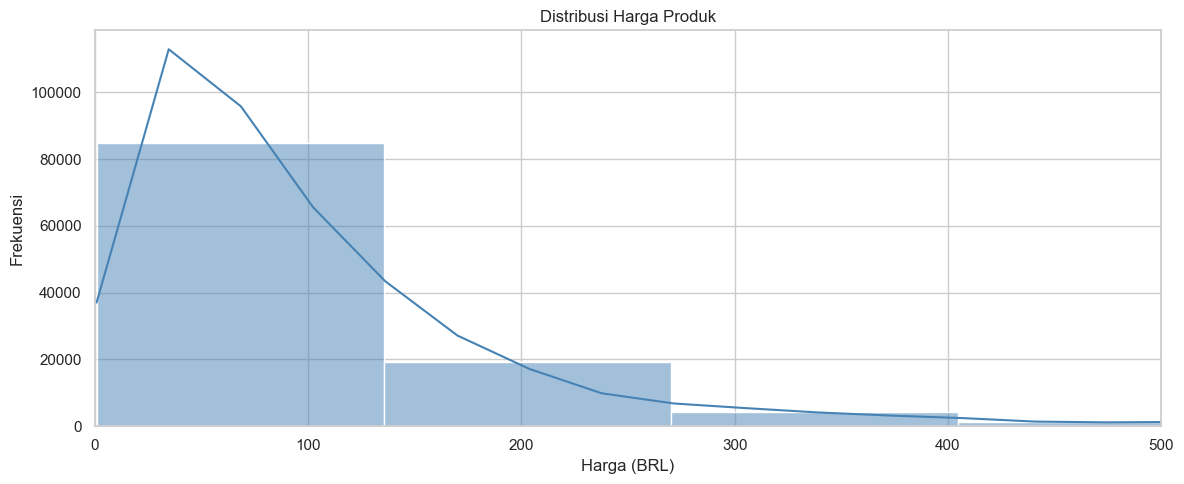

In [12]:
plt.figure()
sns.histplot(df['price'], bins=50, color='steelblue', kde=True)
plt.title('Distribusi Harga Produk')
plt.xlabel('Harga (BRL)')
plt.ylabel('Frekuensi')
plt.xlim(0, 500)  # fokus ke harga wajar
plt.tight_layout()
plt.savefig('../results/distribusi_harga.png', dpi=150)
plt.show()